# **Pipeline 3: Hybrid Multi-Domain Enhancement Pipeline**


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def xray_hybrid_pipeline(
    image_path,
    d0=30,
    alpha=0.5,
    amp=1.5,
    clahe_clip=2.0,
    gamma=0.9,
    w_freq=0.5,
    show=True
):

    # 1. Grayscale
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if original is None:
        raise ValueError("Invalid image path")

    img = original.astype(np.float32)


    # SPATIAL BRANCH
    spatial = cv2.blur(img, (3, 3))

    clahe = cv2.createCLAHE(
        clipLimit=clahe_clip,
        tileGridSize=(8, 8)
    )
    spatial = clahe.apply(spatial.astype(np.uint8)).astype(np.float32)

    spatial = (spatial / 255.0) ** gamma * 255.0

    blur = cv2.GaussianBlur(spatial, (3, 3), 0)
    spatial = spatial + 0.4 * (spatial - blur)

    spatial = cv2.normalize(spatial, None, 0, 255, cv2.NORM_MINMAX)


    #  FREQUENCY BRANCH
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    H = np.zeros((rows, cols), dtype=np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow)**2 + (v - ccol)**2)
            H[u, v] = 1 / (1 + (d0 / (D + 1e-5))**4)

    fshift_filtered = (alpha * fshift) + ((1 - alpha) * fshift * H)
    fshift_filtered *= amp

    img_freq = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_freq = np.abs(img_freq)

    img_freq = cv2.normalize(img_freq, None, 0, 255, cv2.NORM_MINMAX)

    #  HYBRID FUSION
    hybrid = (
        w_freq * img_freq +
        (1 - w_freq) * spatial
    )

    hybrid = np.clip(hybrid, 0, 255).astype(np.uint8)

    # DISPLAY
    if show:

        plt.figure(figsize=(12, 8))

        # 1. Original
        plt.subplot(2, 2, 1)
        plt.title("Original X-ray")
        plt.imshow(original, cmap="gray")
        plt.axis("off")

        # 2. Spatial enhancement
        plt.subplot(2, 2, 2)
        plt.title("Spatial Enhancement")
        plt.imshow(spatial.astype(np.uint8), cmap="gray")
        plt.axis("off")

        # 3. Frequency enhancement
        plt.subplot(2, 2, 3)
        plt.title("Frequency Enhancement")
        plt.imshow(img_freq.astype(np.uint8), cmap="gray")
        plt.axis("off")

        # 4. Hybrid result
        plt.subplot(2, 2, 4)
        plt.title("Hybrid Result")
        plt.imshow(hybrid, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return original, spatial.astype(np.uint8), img_freq.astype(np.uint8), hybrid

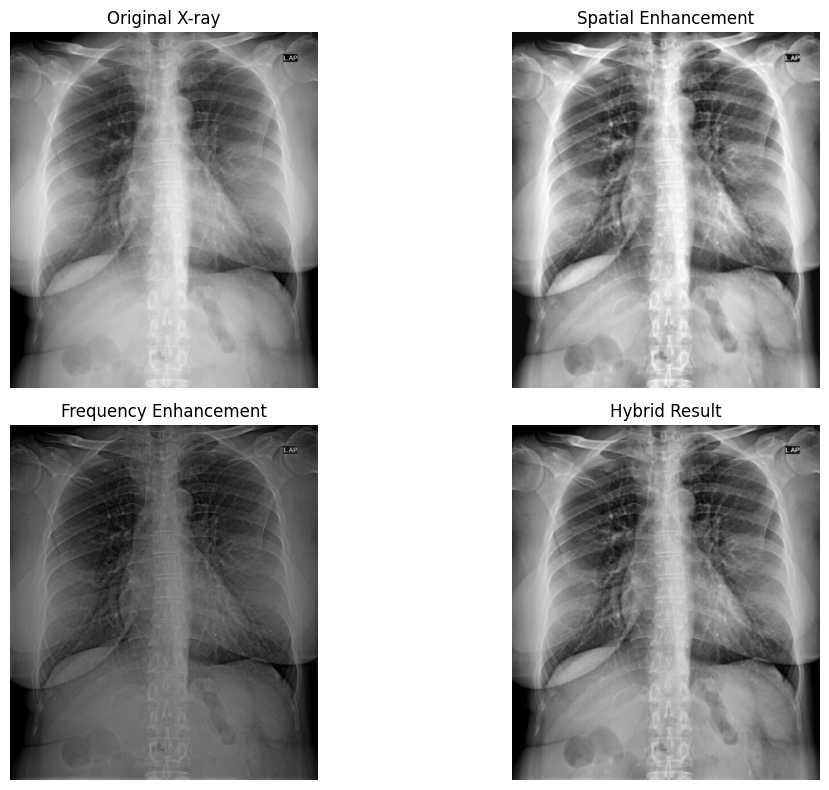

In [ ]:
original, spatial, freq, hybrid = xray_hybrid_pipeline( "/content/fractured rib.jpeg")

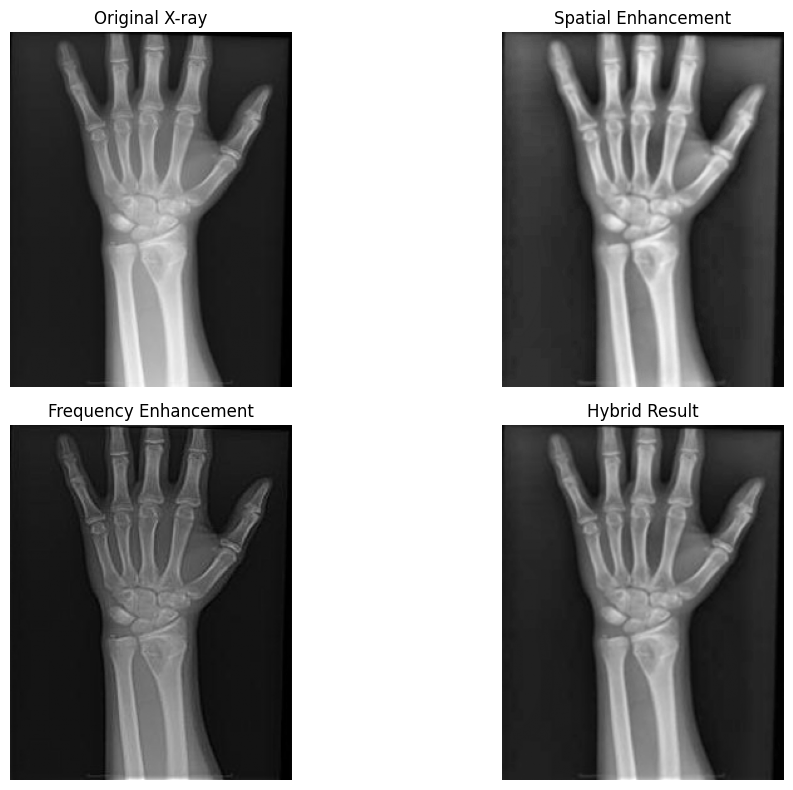

In [ ]:
original, spatial, freq, hybrid= xray_hybrid_pipeline( "/content/img.jpg")

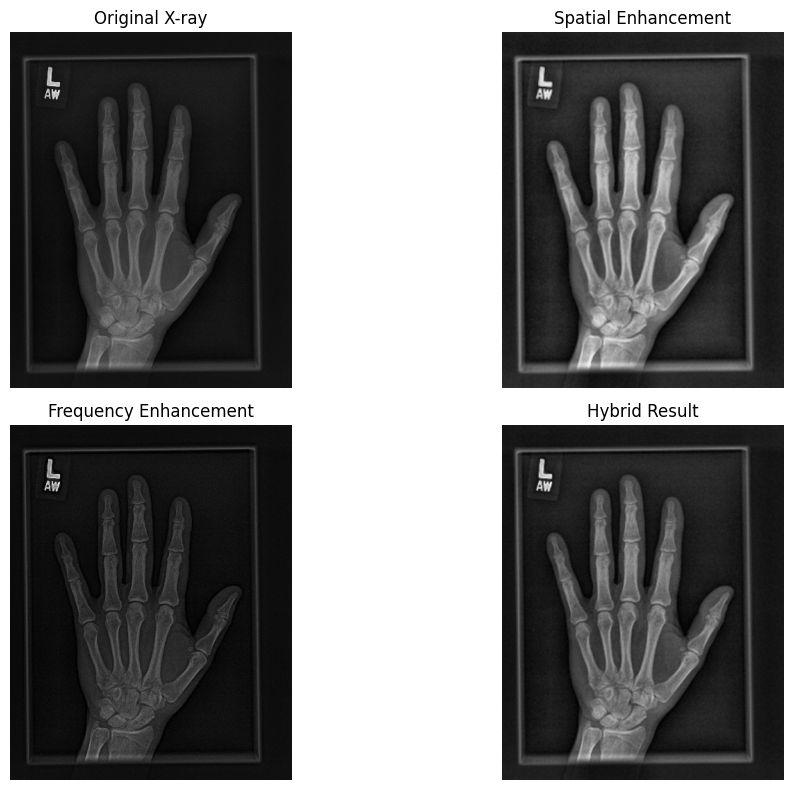

In [ ]:
original, spatial, freq, hybrid= xray_hybrid_pipeline( "/content/image3.png")